In [9]:
import numpy as np
import rasterio
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

Testing pipeline on one scene 

In [7]:
band_folder = r"F:\data_water\processed\bands"
band_files = os.listdir(band_folder)
gebco_file = r"F:\data_water\gebco_reprojected.tif"

In [10]:
with rasterio.open(os.path.join(band_folder, band_files[0])) as src:
    bands = src.read().astype('float32')

with rasterio.open(gebco_file) as src:
    depth = src.read(1).astype('float32')

depth = np.where(depth == -32767.0, np.nan, depth)

shallow_mask = (
    (depth <= 0) &
    (depth >= -30) &
    (~np.isnan(bands[0])) &
    (~np.isnan(bands[1]))               # ta use only pixels that is valid in the areas of depth till 30m
    )            

print('training pixels', shallow_mask.sum())

b02 = bands[0][shallow_mask]
b03 = bands[1][shallow_mask]

y = np.abs(depth[shallow_mask])

print("Depth range:", y.min(), "to", y.max(), "m")


training pixels 1776446
Depth range: 9.350316e-05 to 29.999987 m


 Stumpf band ratio

 ratio = ln(Blue) / ln(Green)
 
 Need to handle negative log values — add small epsilon

In [12]:
epsilion = 1e-10
ratio = np.log(b02 + epsilion) / np.log(b03 + epsilion)

print("Ratio min/max: ", ratio.min(), ratio.max())

# Remove any infinite or NaN ratio values
valid = np.isfinite(ratio)
ratio_clean = ratio[valid]
y_clean = y[valid]

print("Clean samples:", len(ratio_clean))

X_lr = ratio_clean.reshape(-1, 1)   # shape (n_samples, 1)

lr = LinearRegression()
lr.fit(X_lr, y_clean)

print("\n=== Baseline Linear Regression ===")
print("Slope (m1):", round(lr.coef_[0], 4))
print("Intercept (m0):", round(lr.intercept_, 4))

y_pred = lr.predict(X_lr)

r2   = r2_score(y_clean, y_pred)
rmse = np.sqrt(mean_squared_error(y_clean, y_pred))
mae  = mean_absolute_error(y_clean, y_pred)

print("\n=== Accuracy Metrics ===")
print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.4f} m")
print(f"MAE:  {mae:.4f} m")

Ratio min/max:  0.61342937 8.35741
Clean samples: 1776446

=== Baseline Linear Regression ===
Slope (m1): -42.0297
Intercept (m0): 55.8738

=== Accuracy Metrics ===
R²:   0.1007
RMSE: 7.1074 m
MAE:  5.8759 m


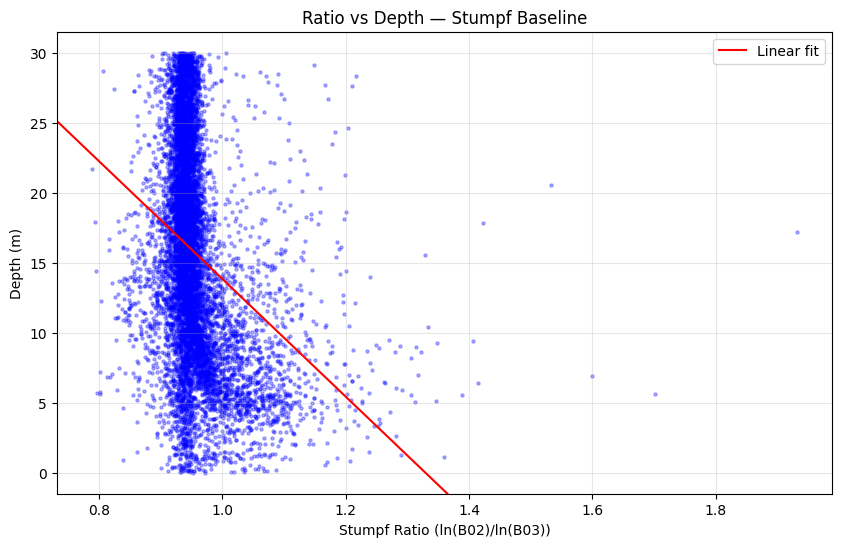

In [13]:
# Sample 10000 points for visualization
idx = np.random.choice(len(ratio_clean), 10000, replace=False)

plt.figure(figsize=(10, 6))
plt.scatter(ratio_clean[idx], y_clean[idx], 
            alpha=0.3, s=5, c='blue')
plt.xlabel('Stumpf Ratio (ln(B02)/ln(B03))')
plt.ylabel('Depth (m)')
plt.title('Ratio vs Depth — Stumpf Baseline')
plt.axline((ratio_clean.mean(), lr.intercept_ + lr.coef_[0]*ratio_clean.mean()),
            slope=lr.coef_[0], color='red', label='Linear fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Most points clustered vertically at ratio 0.85-1.05
→ Almost ALL depths (0-30m) have the same ratio value
→ The ratio is NOT changing with depth

A few outlier points scattered to the right (ratio > 1.2)
→ These are bad pixels — unusual spectral values
→ Pulling the linear fit in the wrong direction

In [14]:
# Filter outliers
clean = (ratio_clean < 1.5) & (ratio_clean > 0.7)
ratio_filtered = ratio_clean[clean]
y_filtered = y_clean[clean]

print("Pixels after outlier removal:", len(ratio_filtered))

# Refit
X_filtered = ratio_filtered.reshape(-1, 1)
lr2 = LinearRegression()
lr2.fit(X_filtered, y_filtered)

y_pred2 = lr2.predict(X_filtered)
r2_2 = r2_score(y_filtered, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_filtered, y_pred2))

print(f"R² after filtering: {r2_2:.4f}")
print(f"RMSE after filtering: {rmse_2:.4f} m")

Pixels after outlier removal: 1775593
R² after filtering: 0.1143
RMSE after filtering: 7.0531 m


Stumpf Baseline Results:
R²:   0.11  → poor, as expected for coarse reference data
RMSE: 7.05m → ~25% of total depth range
MAE:  ~5.8m

Conclusion: Linear band ratio insufficient for this coastal area
→ motivates need for ML approach

In [ ]:

bands_folder  = r"F:\data_water\processed\bands"
emodnet_file  = r"F:\data_water\gebco_reprojected.tif"

# Load EMODnet once — same for all scenes
with rasterio.open(emodnet_file) as src:
    depth = src.read(1).astype('float32')
depth = np.where(depth == -32767.0, np.nan, depth)

# Pre-compute shallow mask from depth only
depth_shallow_mask = (depth < 0) & (depth >= -30)

all_b02   = []
all_b03   = []
all_b04   = []
all_depth = []

for fname in sorted(os.listdir(bands_folder)):
    if not fname.endswith('.tif'):
        continue
    
    fpath = os.path.join(bands_folder, fname)
    
    with rasterio.open(fpath) as src:
        bands = src.read().astype('float32')
    
    # Combined mask — shallow depth AND valid pixels
    mask = (
        depth_shallow_mask &
        (~np.isnan(bands[0])) &
        (~np.isnan(bands[1])) &
        (~np.isnan(bands[2]))
    )
    
    if mask.sum() == 0:
        print(f"No valid pixels: {fname}")
        continue
    
    all_b02.append(bands[0][mask])
    all_b03.append(bands[1][mask])
    all_b04.append(bands[2][mask])
    all_depth.append(np.abs(depth[mask]))
    
    print(f"{fname}: {mask.sum()} pixels")

# Concatenate all scenes
b02   = np.concatenate(all_b02)
b03   = np.concatenate(all_b03)
b04   = np.concatenate(all_b04)
y_all = np.concatenate(all_depth)

print(f"\nTotal training pixels: {len(y_all):,}")
print(f"Depth range: {y_all.min():.2f} to {y_all.max():.2f} m")

No valid pixels: Bands 20240117.tif
No valid pixels: Bands 20240127.tif
No valid pixels: Bands 20240206.tif
Bands 20240224.tif: 1774465 pixels
Bands 20240310.tif: 1776006 pixels
No valid pixels: Bands 20240327.tif
Bands 20240330.tif: 1776446 pixels
No valid pixels: Bands 20240401.tif
Bands 20240404.tif: 1571063 pixels
No valid pixels: Bands 20240406.tif
Bands 20240414.tif: 1772929 pixels
No valid pixels: Bands 20240426.tif
No valid pixels: Bands 20240506.tif
No valid pixels: Bands 20240516.tif
Bands 20240524.tif: 1767639 pixels
No valid pixels: Bands 20240531.tif
No valid pixels: Bands 20240605.tif
Bands 20240608.tif: 1766206 pixels
No valid pixels: Bands 20240610.tif
Bands 20240613.tif: 1746382 pixels
No valid pixels: Bands 20240615.tif
No valid pixels: Bands 20240618.tif
No valid pixels: Bands 20240620.tif
Bands 20240623.tif: 1769265 pixels
No valid pixels: Bands 20240625.tif
Bands 20240628.tif: 1764685 pixels
No valid pixels: Bands 20240630.tif
Bands 20240708.tif: 1768634 pixels
No 

RasterioIOError: F:\data_water\processed\bands\Bands 20250901.tif: No such file or directory

: 